In [1]:
# %pip install scikit-learn
# %pip install category_encoders
# %pip install imbalanced-learn
# %pip install xgboost
# %pip install shap
# %pip show numpy
# %pip install --upgrade "numpy<=2.1"

In [2]:
import numpy as np
import pandas as pd
import random
import os 

### Encoding libaries
# import category_encoders as ce
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
# from imblearn.over_sampling import SMOTE

### Machine Learning
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

### Model Search and Evaluation
from collections import Counter
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, roc_auc_score, roc_curve, accuracy_score, f1_score, precision_score, recall_score, average_precision_score
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc
from sklearn.inspection import permutation_importance

### Plot library
from xgboost import plot_importance
import matplotlib.pyplot as plt
import seaborn as sns
import shap
shap.initjs()

C:\Users\jleel\Documents\2024 Documents\bank_marketing_prediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
### Ignore Warnings
import warnings 
warnings.filterwarnings("ignore")

In [4]:
### Set random number generator
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

## Bank Marketing: Encoding and Modelling

### 0. Data Loading and Feature Engineering

#### 0.1 Data Loading

In [8]:
bank_df = pd.read_csv(".//data//bank-full//bank-full.csv", sep=";")
# bank_df.head(5)

#### 0.2 Feature Engineering with pdays
- Following the exploratory data analysis, we separate feature 'pdays' into previous contact status 'pcont' and for previously contacted clients 'pcdays' for previous contacted days. For clients who 'pcont' status is negative, the 'pcdays' will be recored as 0 since the original 'pdays' starts with 1 for contacted clients.
- As for age, although categorized age into age range would provide comprehensible variable analysis during feature selection and evaluation. As our goal for this model is to predict, we will prioritize retaining information by using numerical variable instead of using a catagorized age variable.

In [10]:
### pdays
pdays_idx = bank_df.columns.get_loc("pdays")
bank_df.insert(
    pdays_idx + 1, # insert behind pdays
    "pcont", 
    np.where(bank_df["pdays"] == -1, "no", "yes") # new variable
)  

## Retain original pdays
pcont_idx = bank_df.columns.get_loc("pcont")
bank_df.insert(
    pcont_idx + 1,
    "pcdays",
    np.where(bank_df["pdays"] == -1, 0, bank_df["pdays"]) # if it is -1 change it to zero.
)

## remove the orignal pdays
pdays = bank_df.pop("pdays") # original pdays

In [11]:
bank_df.head(5)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pcont,pcdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,no,0,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,no,0,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,no,0,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,no,0,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,no,0,0,unknown,no


#### 0.3 Get Subset of Stratified Data
As we would like to explore multiple algorithms for this data, we will use a subset of data to train and test each models. This is to shortern the time to train each of the models.

In [13]:
def get_stratified_subset(df, target_col, pct, rnd_seed=42, insights=False):
    """
    Sample a subset of data specified in percentage from the original dataset. The algorithm functions by going through 
    each of the class in the 'target column' and sampled a proportion equal to the specified percentage.
    """
    ## Check user inputs
    if not isinstance(df, pd.DataFrame):
        raise TypeError(f"Error: Expected a pandas DataFrame, but received a {type(df)}.")
    
    subset_df = pd.DataFrame()
    
    ## Clone and shuffle
    clone_df = df.copy()
    clone_df = clone_df.sample(frac=1, random_state=rnd_seed).reset_index(drop=True) # random shuffling
    
    ## Group data
    tvars = clone_df[target_col].unique() # create target variables list
    for tvar in tvars:
        grouped_tvar = clone_df[clone_df[target_col]==tvar] # get subset data
        n_grouped_tvar = len(grouped_tvar) # get length
        sample_n = int(n_grouped_tvar * pct) # get the number that we need to sample
        sampled_tvar = grouped_tvar.sample(
            n=sample_n, # the number that we need to get to retain that sample pct
            random_state=rnd_seed # ensure reproducibility
        )
        subset_df=pd.concat(
            [subset_df, sampled_tvar],
            ignore_index=True
        )

    ## Reshuffle the grouped data
    subset_df = subset_df.sample(frac=1, random_state=rnd_seed).reset_index(drop=True)

    ## Get insights
    if insights == True:
        ## Get values
        og_counts = df[target_col].value_counts()
        og_pct = round(df[target_col].value_counts(normalize=True)*100, 2)
        sampled_counts = subset_df[target_col].value_counts()
        sampled_pct = round(subset_df[target_col].value_counts(normalize=True)*100, 2)
        ## Visualize
        compare_df = pd.DataFrame({
            "Class": og_counts.index,
            "Original_Count": og_counts.values,
            "Original_PCT": og_pct.values,
            "Sampled_Count": sampled_counts.values,
            "Sampled_PCT": sampled_pct.values
        })
        display(compare_df)
        
    ## Return the sampled data
    return subset_df

In [14]:
subset_bank = get_stratified_subset(
    df=bank_df, 
    target_col="y",
    pct=0.4,
    rnd_seed=SEED,
    insights=True
)

,Class,Original_Count,Original_PCT,Sampled_Count,Sampled_PCT
0,no,39922,88.3,15968,88.3
1,yes,5289,11.7,2115,11.7


#### 1.1 Data Encoding
For data encoding each data column will be treated based on their data types.
- Binary variables (Yes, No) default, housing, loan, and pcont, y will be encoded into 0 for "no" and 1 for "yes".
- Nominal data (No order) job, contact, and poutcome will be OneHot encoding for each of the column category.
- Ordinal data (Categories with order) marital and education will be encode ordinally, representing as 0, 1, 2, ad onwards.
- Cyclical (Seasonal) day and month will be convert into sin and cost to represent seasonal changes.
- Discreate Numerical variables (no encoding required) age, balance, duration, campaign, pcdays, and previous will be scaled to reduce the effect of outliners.

### 1. Modelling Preprocessing 

In [17]:
## Columns
bi_cols = ["default", "housing", "loan", "pcont", "y"]
nom_cols = ["job", "contact", "poutcome"] # onehot encoder
ord_cols = ["education", "marital"]
cyc_cols = ["day", "month"]
dis_cols = ["age", "balance", "duration", "campaign", "pcdays", "previous"] ## We will scale it after all encoding

## Binary and Ordinal Encoding
ord_encoder = OrdinalEncoder(
    categories=[
        ["no", "yes"], ["no", "yes"], ["no", "yes"], ["no", "yes"], ["no", "yes"], # act as binary encoding
        ["unknown", "primary", "secondary", "tertiary"],
        ["single", "married", "divorced"]
    ]
)
## Nominal Encoding
nom_encoder = OneHotEncoder(sparse_output=False)

## Cyclical Encoding
def encode_months(df, month_col):
    months_map = {
        "jan": 1, "feb": 2, "mar": 3, "apr": 4,
        "may": 5, "jun": 6, "jul": 7, "aug": 8,
        "sep": 9, "oct": 10, "nov": 11, "dec": 12
    }
    clone_df = df.copy() # create a clone

    ## Create Sin and Cos for month
    clone_df[month_col] = clone_df[month_col].map(months_map)
    month_sin = np.sin(clone_df[month_col] * (2.*np.pi/12))
    month_cos = np.cos(clone_df[month_col] * (2.*np.pi/12))

    ## Insert new column after the original column
    month_idx = clone_df.columns.get_loc(month_col)
    clone_df.insert(month_idx+1, "month_sin", month_sin)
    clone_df.insert(month_idx+2, "month_cos", month_cos)
    clone_df.drop(columns=[month_col], inplace=True) # drop original column
    return clone_df

def encode_days(df, day_col):
    clone_df = df.copy()
    day_sin = np.sin(clone_df[day_col] * (2.*np.pi/31))
    day_cos = np.cos(clone_df[day_col] * (2.*np.pi/31))

    ## Insert new columns after the original column
    day_idx = clone_df.columns.get_loc(day_col)
    clone_df.insert(day_idx+1, "day_sin", day_sin)
    clone_df.insert(day_idx+2, "day_cos", day_cos)
    clone_df.drop(columns=[day_col], inplace=True) # drop original column
    return clone_df

In [18]:
## Encoding process
## Cyclincal Encoding
encoded_bank = encode_days(subset_bank, "day")
encoded_bank = encode_months(encoded_bank, "month")

## Binary and Ordinal Encoding
encoded_bank[bi_cols+ord_cols] = ord_encoder.fit_transform(encoded_bank[bi_cols+ord_cols])

## Nominal Encoding
encoded_nom = pd.DataFrame(
    nom_encoder.fit_transform(encoded_bank[nom_cols]),
    columns=nom_encoder.get_feature_names_out(nom_cols), # new column names
    index=encoded_bank.index  
)
encoded_bank = encoded_bank.drop(columns=nom_cols).join(encoded_nom)

## Check After encode
encoded_bank.head(5)

,age,marital,education,default,balance,housing,loan,day_sin,day_cos,month_sin,...,job_technician,job_unemployed,job_unknown,contact_cellular,contact_telephone,contact_unknown,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
0,39,0.0,2.0,0.0,-114,1.0,0.0,0.571268,0.820763,8.660254e-01,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,30,0.0,3.0,0.0,596,0.0,0.0,0.724793,0.688967,1.224647e-16,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,34,2.0,2.0,0.0,-28,1.0,0.0,0.937752,0.347305,8.660254e-01,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,29,1.0,2.0,0.0,2121,0.0,0.0,-0.101168,-0.994869,8.660254e-01,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,48,1.0,2.0,0.0,3008,1.0,1.0,-0.485302,-0.874347,-5.000000e-01,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


#### 1.2 Data Split, Scaling, and Resampling

In [20]:
### Apply stratified sampling 70-30 ratio for train-test
X = encoded_bank.drop(columns = ["y"], axis = 1)
y = encoded_bank["y"]

## Train and Check (Test and Validate)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size = 0.3, # get 70% for training
    random_state = SEED, 
    stratify=y
) 

## Test and Validate - Validation occurs within the GridSearch
# X_val, X_test, y_val, y_test = train_test_split(
#     X_check, y_check, 
#     test_size=1/3, 
#     random_state=SEED, 
#     stratify=y_check # get 10% for val and 20% test
# ) 

#### 1.3 Data Scaling
Data Scaling is applied to provide a fair comparision between variables as numerical variable range in the data differs significatly from one another.

In [22]:
### Scaling - Only on discrete numerical columns
num_scaler = StandardScaler()
num_scaler.fit(X_train[dis_cols]) # using Standard Scaler fit to traning data to prevent leakage

## Transform only specific columns
X_train[dis_cols] = num_scaler.transform(X_train[dis_cols]) 
X_test[dis_cols] = num_scaler.transform(X_test[dis_cols]) 
# X_val[dis_cols] = num_scaler.transform(X_val[dis_cols])  

#### 1.4 Class Weighting
As our data is imbalanced with more non-subscribed compared to subscribed clients. We will be experimenting with [class weighting](https://scikit-learn.org/stable/modules/generated/sklearn.utils.class_weight.compute_class_weight.html) in this study. Where machine learning model is penalized based on the proportion of classes.

In [24]:
## Compute class weight for imbalanced dataset
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(zip(np.unique(y_train), class_weights)) # transform into dict
sample_weights = np.array([class_weights[label] for label in y_train]) # assign weight to each y_training

In [25]:
print(class_weights)

{np.float64(0.0): np.float64(0.5662014671676507), np.float64(1.0): np.float64(4.276351351351352)}


### 2. Data Modelling and Hyperparameter Search
In this study we will be exploring Decision Tree, Random Forest, Adaboost, XGBoost, Logistic Regression, and Support Vector Machine models. To understand which parameters should be pioritized for this business problem we will explore confusion matrix to rationalize which modelling parameters to be focus on. <br>

**Confusion Matrix**
|  | Actual Positive| Actual Negative |
| --- | --- | --- |
| **Predicted Positive** | True Positive (TP): subscribed clients correctly predicted as a subscribed client.  | False Positive (FP): non-subscribed clients predicted as a subscribed client. |
| **Predicted Negative** | False Negative (FN): subscribed clients who were predicted as a non-subscribed client. | True Negative (TN): non-subscribed clients who were predicted as a non-subscribed client. |

**Binary Classification Metrics**<br>
For binary classification the important metrics are as follows:

- Accuracy ($\frac{TP + TN}{TP + TN + FN + FP} $)
  
- True Positive Rate or Recall ($\frac{TP}{TP + FN} $)

- True Negative Rate or Specificity/Selectivity ($\frac{TN}{TN + FP} $)

- Balanced Accuracy ($ \frac{Recall + Specificity}{2} $)

- Precision ($ \frac{TP}{TP + FP} $)

- F1 ($ \frac{2 \times \text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}} $)
)

**Imbalanced Classes**<br>
With the goal of predicting subscribed clients to the term deposit, we are interested in correctly predicting TP cases and minimizing FN cases to prevent the loss of potential subscribers. FP cases are less costly and tolerable to the goal of the bank marketing campaign as they only leads to additional contacts. Thus the metric that we should focus on is recall. It is a metric that measures the number of true positive prediction out of all positive cases. Thus, models that achieve high recall indicate that they have the ability to identify most of the true positive cases.

**Recommended Articles**
- [Binary Classification Metrics](https://medium.com/towards-data-science/performance-metrics-for-binary-classifier-in-simple-words-be958535db49)
- [Discussion between Precision Recall AUC and AUC in imbalanced dataset](https://stats.stackexchange.com/questions/262616/roc-vs-precision-recall-curves-on-imbalanced-dataset)
- [Kaggle: How to deal with imbalanced dataset](https://www.kaggle.com/code/marcinrutecki/best-techniques-and-metrics-for-imbalanced-dataset)

#### 2.1 Decision Tree

In [28]:
dt_model = DecisionTreeClassifier(
    random_state=SEED,
    class_weight="balanced" # combat with class imbalance
)

In [29]:
dt_params = {
    "max_depth": [5, 10, 20],
    "max_features": ["sqrt", "log2"]
}
scoring_params = {
    "auc": "roc_auc",
    "recall": "recall",
    "pr_auc": make_scorer(average_precision_score)
}

In [30]:
grid_search_dt = GridSearchCV(
    estimator=dt_model,
    param_grid=dt_params,
    scoring=scoring_params,
    refit="recall",
    cv=5,
    return_train_score=True
)
grid_search_dt.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=DecisionTreeClassifier(class_weight='balanced',
                                              random_state=42),
             param_grid={'max_depth': [5, 10, 20],
                         'max_features': ['sqrt', 'log2']},
             refit='recall', return_train_score=True,
             scoring={'auc': 'roc_auc',
                      'pr_auc': make_scorer(average_precision_score, response_method='predict'),
                      'recall': 'recall'})

In [31]:
grid_search_dt.best_params_

{'max_depth': 10, 'max_features': 'sqrt'}

In [32]:
grid_search_dt.best_score_

np.float64(0.7054054054054053)

In [33]:
dt_search_results = pd.DataFrame(grid_search_dt.cv_results_) # store train results

#### 2.2 Random Forest Model

In [35]:
rfc_model = RandomForestClassifier(
    bootstrap=True, 
    random_state=SEED,
    class_weight="balanced" # combat with class imbalance
)

In [36]:
rf_params = {
    "n_estimators": [50, 100, 150],
    "max_depth": [5, 10, 20],
    "max_features": ["sqrt", "log2"],
    "criterion": ["gini", "entropy"]
}
scoring_params = {
    "auc": "roc_auc",
    "recall": "recall",
    "pr_auc": make_scorer(average_precision_score)
}

In [37]:
grid_search_rfc = GridSearchCV(
    estimator=rfc_model,
    param_grid=rf_params,
    scoring=scoring_params,
    refit="recall",
    cv=5,
    return_train_score=True
)
grid_search_rfc.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=RandomForestClassifier(class_weight='balanced',
                                              random_state=42),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [5, 10, 20],
                         'max_features': ['sqrt', 'log2'],
                         'n_estimators': [50, 100, 150]},
             refit='recall', return_train_score=True,
             scoring={'auc': 'roc_auc',
                      'pr_auc': make_scorer(average_precision_score, response_method='predict'),
                      'recall': 'recall'})

In [38]:
grid_search_rfc.best_params_

{'criterion': 'entropy',
 'max_depth': 5,
 'max_features': 'sqrt',
 'n_estimators': 50}

In [39]:
grid_search_rfc.best_score_

np.float64(0.7925675675675675)

In [40]:
rf_search_results = pd.DataFrame(grid_search_rfc.cv_results_) # store train results

#### 2.3 Adaboost Classifier

In [42]:
adb_model = AdaBoostClassifier(
    random_state=SEED
)

In [43]:
adb_params = {
    "n_estimators": [50, 100, 150],
    "learning_rate": [0.1, 1],
}
scoring_params = {
    "auc": "roc_auc",
    "recall": "recall",
    "pr_auc": make_scorer(average_precision_score)
}

In [44]:
grid_search_adb = GridSearchCV(
    estimator=adb_model,
    param_grid=adb_params,
    scoring=scoring_params,
    refit="recall",
    cv=5,
    return_train_score=True
)
grid_search_adb.fit(X_train, y_train, sample_weight=sample_weights)

GridSearchCV(cv=5, estimator=AdaBoostClassifier(random_state=42),
             param_grid={'learning_rate': [0.1, 1],
                         'n_estimators': [50, 100, 150]},
             refit='recall', return_train_score=True,
             scoring={'auc': 'roc_auc',
                      'pr_auc': make_scorer(average_precision_score, response_method='predict'),
                      'recall': 'recall'})

In [45]:
grid_search_adb.best_params_

{'learning_rate': 1, 'n_estimators': 100}

In [46]:
grid_search_adb.best_score_

np.float64(0.8054054054054054)

In [47]:
adb_search_results = pd.DataFrame(grid_search_adb.cv_results_) # store train results

#### 2.4 XGBoost Classifier

In [49]:
xgb_model = XGBClassifier(
    seed=SEED,
    device="cuda"
)

In [50]:
xgb_params = {
    "n_estimators": [50, 100, 150],
    "learning_rate": [0.1, 1],
}
scoring_params = {
    "auc": "roc_auc",
    "recall": "recall",
    "pr_auc": make_scorer(average_precision_score)
}

In [51]:
grid_search_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=xgb_params,
    scoring=scoring_params,
    refit="recall",
    cv=5,
    return_train_score=True
)
grid_search_xgb.fit(X_train, y_train, sample_weight=sample_weights)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device='cuda',
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=Non...
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=None, ...),
             param_grid={'learning_rate': [0.1, 1],
                         'n_estimators': [50, 100, 150]},
             refit='recall', return_train_score=True,
             scoring={'auc': 'roc_auc',
                      'pr_auc': make_scorer(average_precision_score, response_method='predict'),
                      'recall': 'recall'})

In [52]:
grid_search_xgb.best_params_

{'learning_rate': 0.1, 'n_estimators': 50}

In [53]:
grid_search_xgb.best_score_

np.float64(0.845945945945946)

#### 2.5 Logistic Regression

In [55]:
lg_model = LogisticRegression(
    random_state=SEED,
    class_weight="balanced",
    solver="lbfgs"
)

In [56]:
lg_params = {
    "penalty": ["l1", "l2"],
    "C": [0.1, 1],
}
scoring_params = {
    "auc": "roc_auc",
    "recall": "recall",
    "pr_auc": make_scorer(average_precision_score)
}

In [57]:
grid_search_lg = GridSearchCV(
    estimator=lg_model,
    param_grid=lg_params,
    scoring=scoring_params,
    refit="recall",
    cv=5,
    return_train_score=True
)
grid_search_lg.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=LogisticRegression(class_weight='balanced',
                                          random_state=42),
             param_grid={'C': [0.1, 1], 'penalty': ['l1', 'l2']},
             refit='recall', return_train_score=True,
             scoring={'auc': 'roc_auc',
                      'pr_auc': make_scorer(average_precision_score, response_method='predict'),
                      'recall': 'recall'})

In [58]:
grid_search_lg.best_params_

{'C': 1, 'penalty': 'l2'}

In [59]:
grid_search_lg.best_score_

np.float64(0.7925675675675675)

#### 2.6 Support Vector Classifier

In [61]:
svc_model = SVC(
    random_state=SEED,
    class_weight="balanced",
    gamma="scale"
)

In [62]:
svc_params = {
    "kernel": ["linear", "poly", "rbf"],
    "C": [1],
    "degree": [3],
}
scoring_params = {
    "auc": "roc_auc",
    "recall": "recall",
    "pr_auc": make_scorer(average_precision_score)
}

In [63]:
grid_search_svc = GridSearchCV(
    estimator=svc_model,
    param_grid=svc_params,
    scoring=scoring_params,
    refit="recall",
    cv=5,
    return_train_score=True
)
grid_search_svc.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=SVC(class_weight='balanced', random_state=42),
             param_grid={'C': [1], 'degree': [3],
                         'kernel': ['linear', 'poly', 'rbf']},
             refit='recall', return_train_score=True,
             scoring={'auc': 'roc_auc',
                      'pr_auc': make_scorer(average_precision_score, response_method='predict'),
                      'recall': 'recall'})

In [64]:
grid_search_svc.best_params_

{'C': 1, 'degree': 3, 'kernel': 'rbf'}

In [65]:
grid_search_svc.best_score_

np.float64(0.8351351351351353)

### 3. Best Model Training and Comparision |

In [67]:
## Define each model based on the best parameters
dtree = DecisionTreeClassifier(
    max_depth=10, max_features="sqrt", 
    random_state=SEED, class_weight="balanced"
)

rforest = RandomForestClassifier(
    criterion="entropy", max_depth= 5, max_features = "sqrt", 
    n_estimators = 50, bootstrap=True, 
    random_state=SEED, class_weight="balanced"
)

adaboost = AdaBoostClassifier(
    learning_rate=1, n_estimators=100,
    random_state=SEED
)

xgboost = XGBClassifier(
    learning_rate=0.1, n_estimators=50,
    seed=SEED,
    device="cuda",
    predict_proba=True
)

lreg = LogisticRegression(
    C=1, penalty="l2",
    random_state=SEED,
    class_weight="balanced",
    solver="lbfgs"
)

svc = SVC(
    C = 1, degree=3, 
    kernel="rbf",
    random_state=SEED,
    class_weight="balanced",
    probability=True,
    gamma="scale"
)

In [68]:
## Train each of the models - We avoid loop as some models require weight specifications
dtree.fit(X_train, y_train) # weight already specified
rforest.fit(X_train, y_train) # weight already specified
adaboost.fit(X_train, y_train, sample_weight=sample_weights)
xgboost.fit(X_train, y_train, sample_weight=sample_weights)
lreg.fit(X_train, y_train) # weight already specified
svc.fit(X_train, y_train) # weight already specified

SVC(C=1, class_weight='balanced', probability=True, random_state=42)

In [69]:
model_list = {
    "dtree": dtree,
    "rforest": rforest,
    "adaboost": adaboost,
    "xgboost": xgboost,
    "lreg": lreg,
    "svc": svc
}

In [70]:
model_metrics = []
roc_data = []
pr_data = []

## Loop through models
for name, model in model_list.items():    
    ## Get prediction results
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    ## Compute Metrics
    auc_score = roc_auc_score(y_test, y_proba)
    pr_auc_score = average_precision_score(y_test, y_proba)
    acc_score = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    
    ## Store results
    model_metrics.append({
        "model": name,
        "auc": round(auc_score*100, 2),
        "pr_auc": round(pr_auc_score * 100, 2),
        "f1-score": round(f1*100, 2),
        "recall": round(recall*100, 2),
        "precision": round(precision*100, 2),
        "accuracy": round(acc_score*100, 2)
    })

    ## Get ROC
    false_pos_rate, true_pos_rate, thresh = roc_curve(y_test, y_proba)
    roc_data.append({
        "model": name,
        "auc": auc_score, 
        "fpr": false_pos_rate,
        "tpr": true_pos_rate,
        "thresh": thresh
    })

    ## Get Precision Recall Curve
    precision, recall, pr_thresh = precision_recall_curve(y_test, y_proba)
    auc_pr = auc(recall, precision)
    pr_data.append({
        "model": name,
        "auc_pr": auc_pr,
        "precision": precision,
        "recall": recall,
        "thresh": pr_thresh
    })

#### 3.1 Receiver-operating Characteristic Curve (ROC)
Receiver-operating characteristic curve (ROC) calculates model performance by calculating the true positive rate (subscribed clients) and false positive rate (non-subscribed clients) across all possible thresholds. The area under the curve (AUC) presents the probability of the model, with models having an AUG of 1.0 having the perfect probability of randomly choosing a positive class.

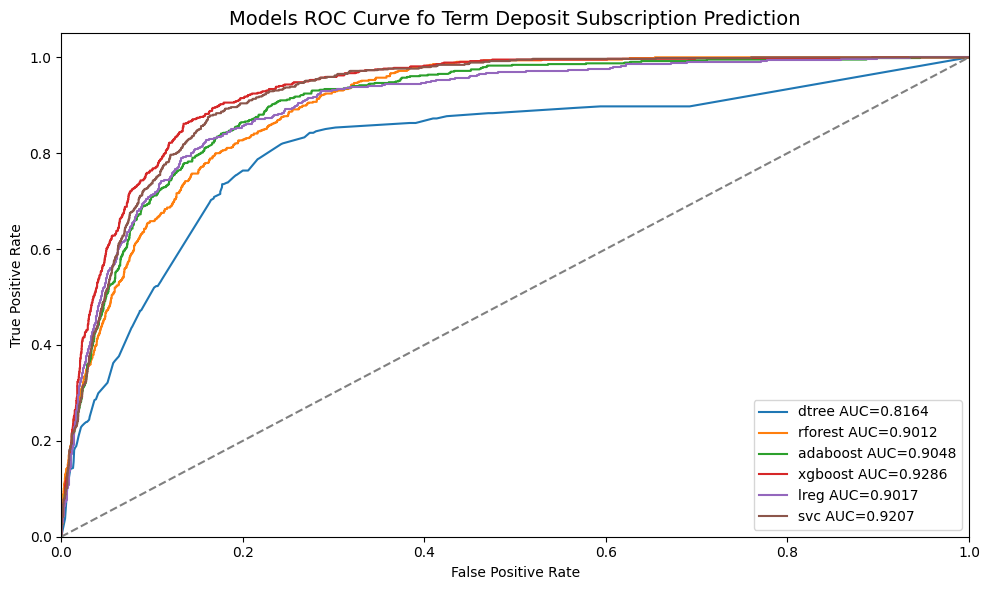

In [172]:
### Compare result for multiple models - ROC Curve
fig = plt.figure(figsize =(10, 6)) 
for entry in roc_data:
    plt.plot(
        entry["fpr"], entry["tpr"], 
        label=f'{entry["model"]} AUC={round(entry["auc"], 4)}'
    )
plt.plot([0, 1], [0, 1], linestyle="--", color="gray") 
plt.title("Models ROC Curve fo Term Deposit Subscription Prediction", fontsize=14)
plt.xlabel("False Positive Rate", fontsize=10)
plt.ylabel("True Positive Rate", fontsize=10)
plt.margins(x=0, y=0) # set every margin to 0
plt.ylim(0, 1.05) # extend to get a gap on top
plt.tight_layout()
plt.legend()
# plt.savefig(".//md_plots//roc-curve.png", bbox_inches="tight")
plt.show();

For this binary classification task, with both classes having equal importance, an AUC of 0.5 is used as a benchmark to compare model performance to the probability of guessing client subscription status. Thus, models with higher AUC are relatively better models. However, as our dataset has imbalanced classes with clients who subscribed to the term deposit significantly less than those who do, the precision and recall curve (PR AUC) that focuses on positive class detection is selected over ROC AUC.

#### 3.2 Precision-Recall Curve
With our focus on identifying positive classes (i.e., subscribers), precisio and recall plot is plotted to identify each model precision and recall trade off. The plot reveals that XGBoost model demonstrates the best performance to identify positive classes at AUC of 0.607 compared to other models.

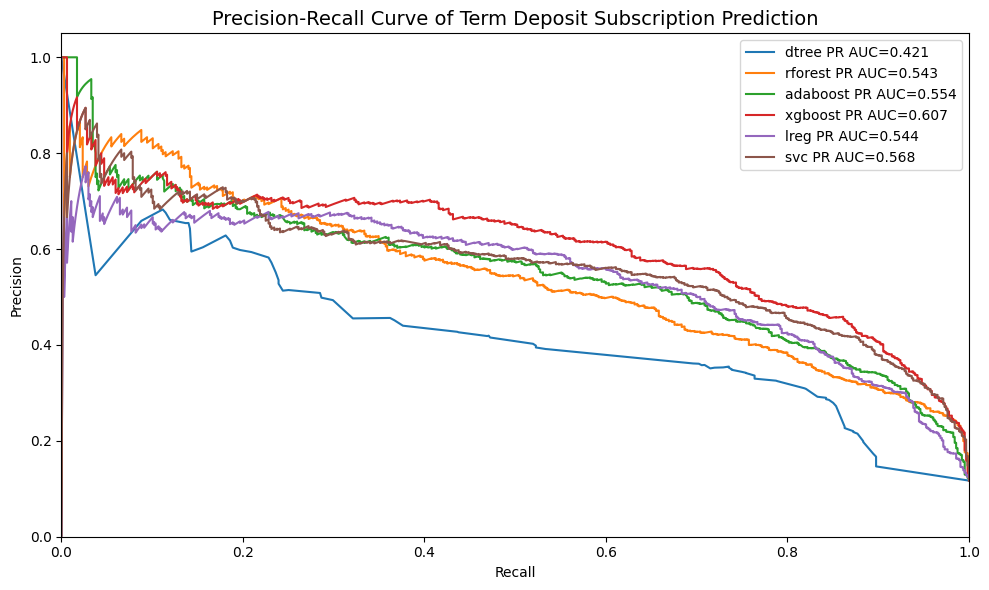

In [182]:
### Compare result for multiple models - ROC Curve
fig = plt.figure(figsize =(10, 6)) 
for entry in pr_data:
    plt.plot(
        entry["recall"], entry["precision"],
        label=f"{entry['model']} PR AUC={entry['auc_pr']:.3f}"
    )
plt.title("Precision-Recall Curve of Term Deposit Subscription Prediction", fontsize=14)
plt.xlabel("Recall", fontsize=10)
plt.ylabel("Precision", fontsize=10)
plt.margins(x=0, y=0) # set every margin to 0
plt.ylim(0, 1.05) # extend to get a gap on top
plt.tight_layout()
plt.legend()
# plt.savefig(".//md_plots//pr-curve.png", bbox_inches="tight")
plt.show();

#### 3.3 Classification Metrics
While PR AUC provides insight into the trade-off among the models and their ability to predict positive classes, other classification metrics are utilized in conjunction to evaluate and identify the most suitable model for this application. As described in the modeling section, our business problem focuses on identifying the subscribed clients (positive classes), making recall the most important metric. Some models have lower precision, indicating that when they predict positive classes, some predictions are not positive classes. Based on these performance requirments, support vector classifer (SVC) would be the best choice with its highest recall. However, we should factor in precision and f1 score as they provided more balance metric for model assessment. Thus, overall XGBoost is the most suitable model with its high recall, F1-score, and the PR AUC.

In [77]:
### Compare result for multiple models - Tabular Data Comparision
model_metric_results = pd.DataFrame(model_metrics)
model_metric_results.sort_values(by=["recall", "pr_auc", "f1-score", "auc", "precision"], ascending=False).reset_index(drop=True)

,model,auc,pr_auc,f1-score,recall,precision,accuracy
0,svc,92.07,56.95,56.25,87.87,41.36,84.00
1,xgboost,92.86,60.73,58.18,87.40,43.60,85.29
2,lreg,90.17,54.56,54.34,82.83,40.43,83.71
3,rforest,90.12,54.38,50.37,81.26,36.49,81.25
4,adaboost,90.48,55.45,54.04,81.10,40.52,83.85
5,dtree,81.64,40.94,46.68,76.38,33.61,79.58


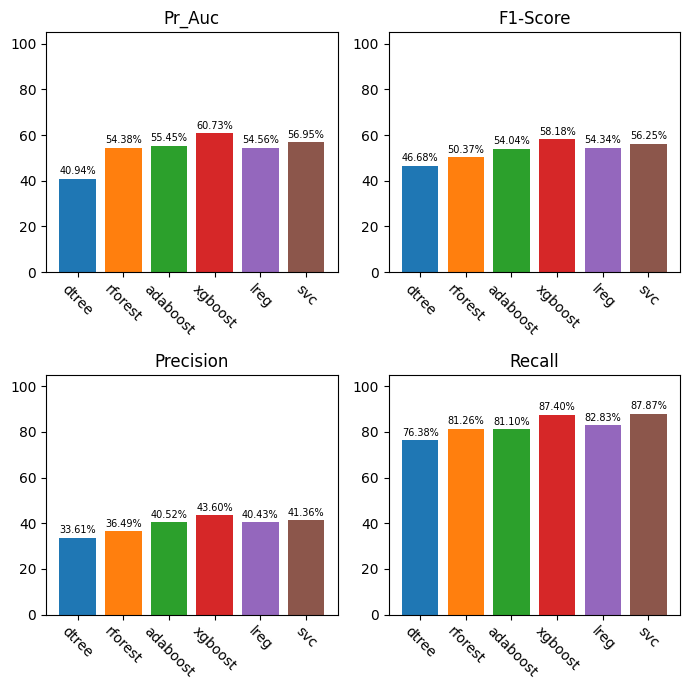

In [176]:
model_colors = {
    "dtree": "#1F77B4", # Blue
    "rforest": "#FF7F0E", # Orange
    "adaboost": "#2CA02C", # green
    "xgboost": "#D62728", # red
    "lreg": "#9467BD", # purple
    "svc": "#8C564B", # brown
} # Color ref: https://scottplot.net/cookbook/5.0/palettes/
plot_metrics = ["pr_auc", "f1-score", "precision", "recall"]

## Loop and Plot
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(7,7))
axs_flat = axs.flatten()
for metric, axis in zip(plot_metrics, axs_flat):
    colors = [model_colors[model] for model in model_metric_results["model"]]
    axis.bar(
        model_metric_results["model"], 
        model_metric_results[metric],
        color=colors # accept only list
    )
    axis.set_title(metric.title())
    axis.set_ylim(0, 105)
    axis.set_xticklabels(model_metric_results["model"], rotation=-45)

    ## Plot Percentage
    for bar in axis.patches:
        axis.text(
            bar.get_x() + bar.get_width()/2, 
            bar.get_height() + 2, 
            f"{bar.get_height():.2f}%", 
            ha="center", fontsize=7, color="black")
plt.tight_layout()
# plt.savefig(".//md_plots//params-comp.png", bbox_inches="tight")
plt.show();

### 4. Most Suitable Model Summary: XGBoost

#### 4.1 XGBoost Model Evaluation with Test Set

In [188]:
def evaluate_model(model_name, y_test, y_predicted, figsize=(6,4), savefig=False, save_path="img.png"):
    model_results = confusion_matrix(y_test, y_predicted)
    plt.figure(figsize=(6,4))
    sns.heatmap(
        model_results, 
        fmt = "d",
        square=True,
        annot=True
    )
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    if savefig==True:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show();
    
    ## Classification Performance
    print(f"{model_name}")
    print("Accuracy:\t%f" % accuracy_score(y_test, y_predicted))
    print("F1-score:\t%f" % f1_score(y_test, y_predicted, average="macro"))
    print("Precision:\t%f" % precision_score(y_test, y_predicted, average="macro"))
    print("Recall:\t\t%f" % recall_score(y_test, y_predicted, average="macro"))
    print(classification_report(y_test, y_predicted))

In [190]:
### XGBoost
y_predicted = xgboost.predict(X_test) # use xgboost algorithm

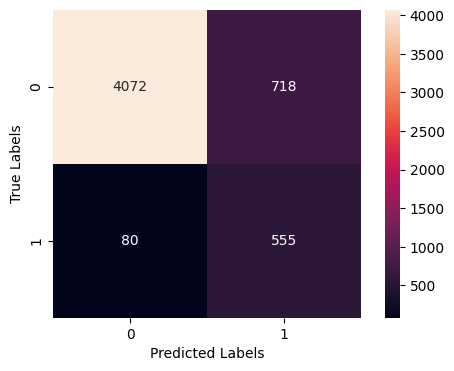

XGBoost Performance
Accuracy:	0.852903
F1-score:	0.746260
Precision:	0.708355
Recall:		0.862060
              precision    recall  f1-score   support

         0.0       0.98      0.85      0.91      4790
         1.0       0.44      0.87      0.58       635

    accuracy                           0.85      5425
   macro avg       0.71      0.86      0.75      5425
weighted avg       0.92      0.85      0.87      5425



In [194]:
### Classification Results
evaluate_model(
    model_name="XGBoost Performance", 
    y_test=y_test, 
    y_predicted=y_predicted,
    savefig=False,
    save_path=".//md_plots//xgb-confusion.png"
)

In [84]:
## While the model saving is 
## Save path
dir_path = os.getcwd()
folder_name = "models"
save_path = os.path.join(dir_path, folder_name)
os.makedirs(save_path, exist_ok=True) # Check if trye

fname = "xgb_model.json" 
file_path = os.path.join(save_path, fname)

## Save model
# xgboost.save_model(file_path)

#### 4.2 XGBoost Feature Importance Plot
To better understand which features contribute to the final prediction, feature importance plots are utilized to determine the most influencial factor.

##### 4.2.1 Feature Importance: Gain
Even though our model has imbalanced classes with the majority of the classes being non-subscribers, the gain calculated feature importance plot would provide insights into the features that improve the overall model accuracy during the branch splitting. Plotting this feature's importance revealed that poutcome_sucess, contact_unknown, and duration are among the top 3 features that contribute to the overall model accuracy. With insights from data exploration, we could identify that poutcome_success from the previous campaign aids the model in identifying subscribed clients as there is a higher proportion of subscribed clients. On the other hand, the majority of the clients who were labeled as contact_unknown are clients who were not contacted in the previous event, having the majority of them being non-subscribers. As for duration, the data exploration suggested that clients who have longer duration tend to subscribe compared to those with shorter duration.

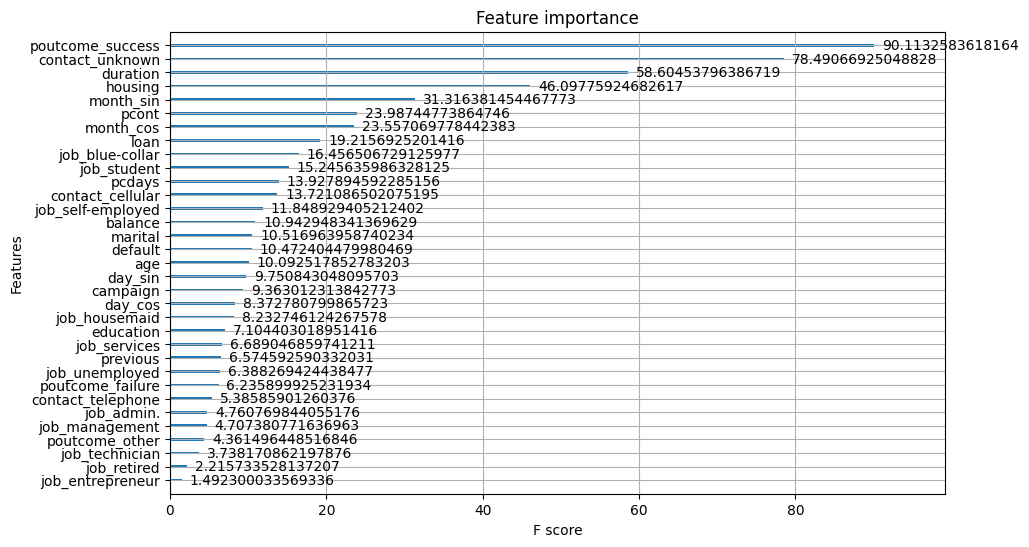

In [87]:
fig, axis = plt.subplots(figsize=(10, 6))
plot_importance(
    xgboost,
    importance_type="gain", # default
    ax=axis
)
# plt.tight_layout()
plt.show();

##### 4.2.2 Feature Importance: Permutation
Feature importance analysis using permuation method, where feature variables are randomly shuffled to measure their impact on model performance, revealed that all poutcome statuses significantly influenced the model. This suggest that the outcome of the previous outcome status plays a crucial role in predicting client's response in the curret campaign. We hypothesized that this client who previously subscribed (i.e., poutcome success) are more likely to subscribe again as EDA suggested. On the other hand, majority of the clients with an unknown poutcome status were not contacted in the previous campaign, making their subscription status in the current campaign unlikely.

In [89]:
permutation_imp = permutation_importance(xgboost, X_test, y_test)

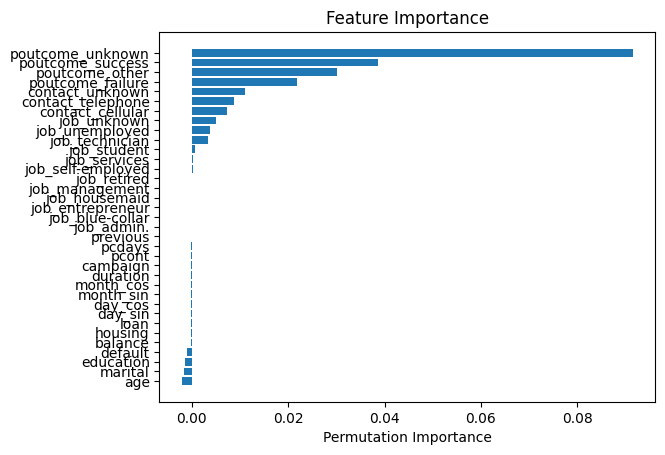

In [90]:
sorted_idx = permutation_imp.importances_mean.argsort()
plt.barh(X_test.columns, permutation_imp.importances_mean[sorted_idx])
plt.title("Feature Importance")
plt.xlabel("Permutation Importance")
plt.show();

##### 4.2.3 Feature Importance: Shap
With the rise of AI explainability, SHapley Additive exPlanations (SHAP), based on game theory, are widely used to evaluate each feature’s contribution to the final model prediction. Based on SHAP force plots, we identified that using the baseline as a reference, duration has the greatest impact in predicting the class within this sample dataset. The summary plot of the test data supports this observation, as duration ranks as the most influential feature. Following this, contact_unknown ranks second, where lower feature values lead the model to predict non-subscribed clients. This finding aligns with the previous two feature importance plots, which indicate that these clients are new to the current campaign, which is a characteristic shared by the majority of clients in this campaign. The third most influential factor is month_sin which can be identified broadly as the period of January to June based on $ \sin\left(\frac{2\pi \times \text{month}}{12}\right) $, suggesting that seasonality has an impact on the final prediction. Unsurprisingly, we hypothesized that this is based on the high number of clients who were contacted in May compared to other months.


In [92]:
explainer = shap.TreeExplainer(xgboost)
shap_values = explainer.shap_values(X_test)
explanation = explainer(X_test)

In [93]:
shap.plots.force(explanation[0]) # non-subscribed clients

In [94]:
shap.plots.force(explanation[1637]) # subscribed clients

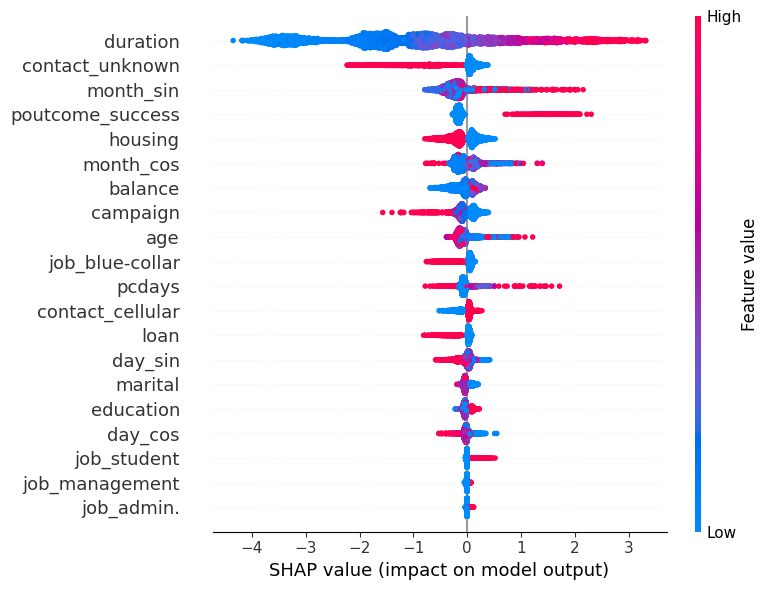

In [184]:
shap.summary_plot(
    shap_values, 
    X_test,
    plot_size=[8,6],
    show=False
)
# plt.savefig(".//md_plots//shap-features", bbox_inches="tight")
plt.show();

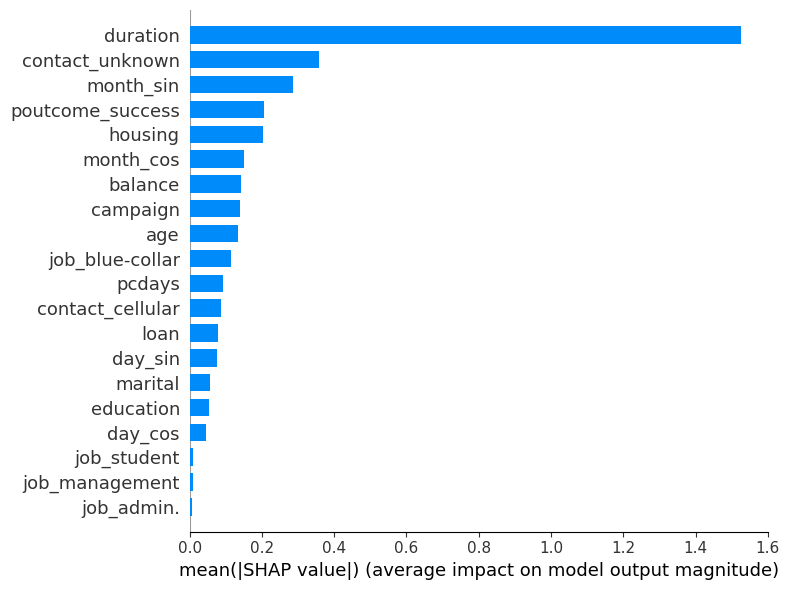

In [96]:
shap.summary_plot(
    shap_values, 
    X_test, 
    plot_type="bar",
    plot_size=[8,6]
)

### 5. Modelling Summary
- This notebook explores predictive modeling to determine client subscription to a term deposit. Due to computational constraints, only a subset of the data was used to evaluate different models.
- Categorical variables were encoded using binary, nominal (OneHot), and ordinal encoding based on distinct feature criteria. Additionally, cyclical encoding was applied to days and months, while numerical variables were normalized to mitigate the impact of outliers.
- Our model goal is to identify potential term deposit subscribers from all clients, so our model tuning focuses on improving recall parameters. This is due to the high cost of misidentifying positive classes as false negatives. Moreover, with imbalanced classes, this study employs class weighting for all models to penalize model classification and focus on the subscribed clients (positive classes).
- Decision Tree, Random Forest, AdaBoost, XGBoost, Logistic Regression, and Support Vector Machine models were trained and compared, focusing on recall, the precision-recall curve, and the F1 score. Based on our analysis, XGBoost was selected as the optimal model due to its high recall and strong overall performance on the precision-recall curve.
- Analyzing feature contributions to XGBoost’s classification decisions revealed that the most influential features were contact duration, previous campaign outcome status, and the month of contact. This finding aligns with our initial data exploration, where these features demonstrated a clear distinction between subscribed and non-subscribed clients.